# 3 — Walk-forward results

Honest, time-respecting evaluation. The model is only ever trained on Olympics that happened *before* the one it is tested on (`WalkForwardOlympicsSplit`), and the country/sport rate features are computed leakage-safely (`leakage.py`). Metrics are PR-AUC / max-F1 / Brier rather than accuracy, because the target is only ~10.8% positive.

All logic lives in `src/medal_predictor`; this notebook just orchestrates and plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

from medal_predictor.data import load_raw, parse_gender
from medal_predictor.features import build_features
from medal_predictor.leakage import compute_past_only_rates
from medal_predictor.cv import WalkForwardOlympicsSplit
from medal_predictor.model import train
from medal_predictor.evaluation import precision_recall_summary, calibration_report, bootstrap_metric
from medal_predictor.betting import simulate_betting, BASELINE_MEDAL_RATE

### Assemble the leakage-safe feature matrix
Each year's rows get country/sport rates built from earlier years only (2008 has no history, so its rates are 0).

In [2]:
df = parse_gender(load_raw('data/raw/olympics.db'))
rate_cols = ['country_medal_rate', 'country_avg_ranking', 'sport_medal_rate', 'sport_avg_ranking']
# Attach past-only rates year by year, then rebuild one matrix.
rated = pd.concat(
    [compute_past_only_rates(df, yr) for yr in sorted(df['participation_year'].unique())],
    ignore_index=True,
)
X, y = build_features(rated)
X = pd.concat([X.reset_index(drop=True), rated[rate_cols].reset_index(drop=True)], axis=1)
years = rated['participation_year'].reset_index(drop=True)
print(f'matrix: {X.shape}  |  medal rate: {y.mean():.1%}')
list(X.columns)

matrix: (20915, 13)  |  medal rate: 10.6%


['height',
 'weight',
 'bmi',
 'gdp_per_capita',
 'age',
 'height_zscore',
 'weight_zscore',
 'gender_Men',
 'gender_Women',
 'country_medal_rate',
 'country_avg_ranking',
 'sport_medal_rate',
 'sport_avg_ranking']

### Walk-forward cross-validation
Three folds: 2008->2012, 2008+2012->2016, 2008+2012+2016->2020. Each row is the out-of-sample score for one future Olympics — no future ever informs the past.

In [3]:
splitter = WalkForwardOlympicsSplit()
rows, final_fold = [], None
for train_idx, test_idx in splitter.split(years):
    model = train(X.iloc[train_idx], y.iloc[train_idx])
    scores = model.predict_proba(X.iloc[test_idx])[:, 1]
    y_test = y.iloc[test_idx].to_numpy()
    summary = precision_recall_summary(y_test, scores)
    rows.append({'test_year': int(years.iloc[test_idx].iloc[0]), 'n_test': len(test_idx), **summary})
    final_fold = (y_test, scores)  # keep the last (2020) fold for the plots
results = pd.DataFrame(rows)
results.round(3)

,test_year,n_test,pr_auc,average_precision,max_f1,max_f1_threshold
0,2012,5717,0.126,0.127,0.208,0.096
1,2016,6293,0.243,0.245,0.320,0.172
2,2020,2691,0.300,0.305,0.360,0.171


### Precision-recall curve (final fold: predict 2020)
PR is the right lens on an imbalanced target — it ignores the easy true-negatives that inflate accuracy and AUC-ROC.

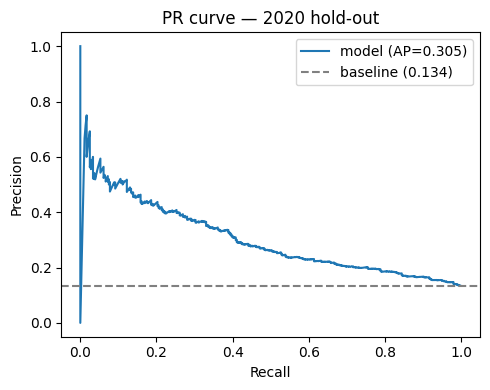

In [4]:
y_test, scores = final_fold
precision, recall, _ = precision_recall_curve(y_test, scores)
ap = average_precision_score(y_test, scores)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(recall, precision, label=f'model (AP={ap:.3f})')
ax.axhline(y_test.mean(), ls='--', color='grey', label=f'baseline ({y_test.mean():.3f})')
ax.set(xlabel='Recall', ylabel='Precision', title='PR curve — 2020 hold-out')
ax.legend()
fig.tight_layout()

### Calibration (are stated probabilities honest?)
A well-calibrated model sits on the diagonal: among athletes it rates at p, about p actually medal. The Brier score summarises this in one number.

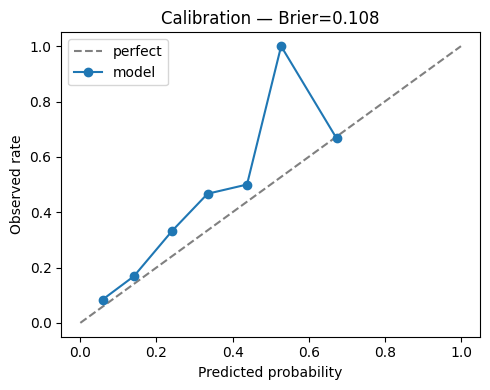

In [5]:
cal = calibration_report(y_test, scores, n_bins=10)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='perfect')
ax.plot(cal['prob_pred'], cal['prob_true'], 'o-', label='model')
ax.set(xlabel='Predicted probability', ylabel='Observed rate', title=f"Calibration — Brier={cal['brier']:.3f}")
ax.legend()
fig.tight_layout()

### Bootstrap confidence interval
A point estimate without an interval is a guess. 95% CI for average precision on the 2020 hold-out, via 1000 bootstrap resamples.

In [6]:
lo, hi = bootstrap_metric(y_test, scores, average_precision_score, n=1000)
print(f'Average precision (2020): {ap:.3f}  95% CI [{lo:.3f}, {hi:.3f}]')

Average precision (2020): 0.305  95% CI [0.262, 0.357]


### Betting framing — is the edge worth anything?
Treat each probability as a bet against the naive market line (the ~10.8% base rate). Bet 1 unit on every athlete the model rates above a threshold; sweep the threshold and watch ROI per unit staked.

,threshold,n_bets,total_pnl,roi,hit_rate,sharpe
0,0.10,875.0,1041.667,1.190,0.237,0.303
1,0.15,496.0,874.370,1.763,0.298,0.416
2,0.20,293.0,716.259,2.445,0.372,0.546
3,0.25,158.0,471.630,2.985,0.430,0.651
4,0.30,65.0,240.556,3.701,0.508,0.799
5,0.35,31.0,135.667,4.376,0.581,0.958
6,0.40,20.0,91.111,4.556,0.600,1.004
7,0.45,12.0,62.074,5.173,0.667,1.185
8,0.50,8.0,47.556,5.944,0.750,1.483
9,0.55,6.0,31.037,5.173,0.667,1.185


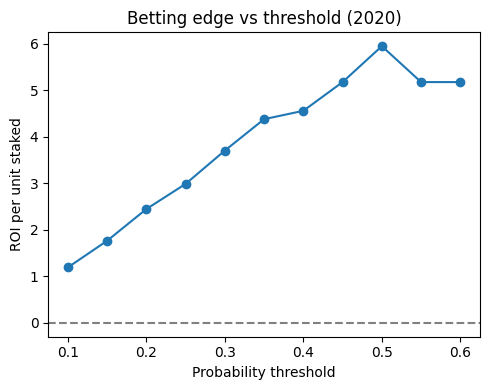

In [7]:
thresholds = np.linspace(0.1, 0.6, 11)
sims = pd.DataFrame(
    [{'threshold': round(float(t), 3), **simulate_betting(scores, y_test, t)} for t in thresholds]
)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(sims['threshold'], sims['roi'], 'o-')
ax.axhline(0, ls='--', color='grey')
ax.set(xlabel='Probability threshold', ylabel='ROI per unit staked', title='Betting edge vs threshold (2020)')
fig.tight_layout()
sims.round(3)